Agentic RAG LangGraph

In [19]:
import os
from typing import TypedDict ,List
from langgraph.graph import StateGraph,END
from langchain_community.vectorstores import FAISS
from langchain_core.documents import Document
from langchain_community.document_loaders import PyPDFDirectoryLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

In [22]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [21]:
#Openai API key from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
#Initializing model
llm=ChatGroq(model='llama-3.3-70b-versatile',temperature=0)
embeddings=HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

In [23]:
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x000001B2599EA510>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001B2599EB230>, model_name='llama-3.3-70b-versatile', temperature=1e-08, model_kwargs={}, groq_api_key=SecretStr('**********'))

State Definition

In [24]:
class AgentState(TypedDict):
    question : str
    documents:List[Document]
    answer:str
    needs_retrieval:bool

In [25]:
from langchain_huggingface import HuggingFaceEmbeddings
#Sample document and VectoreStore
embeddings = HuggingFaceEmbeddings()

# Load all PDFs from folder
loader = PyPDFDirectoryLoader("../data/pdf")
documents = loader.load()

# Split into chunks
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
split_docs = text_splitter.split_documents(documents)

# Create vector store
vectorstore = FAISS.from_documents(split_docs, embeddings)
retriever = vectorstore.as_retriever(k=3)

Agents Function

In [26]:
def decide_retrieval(state:AgentState) -> AgentState:
    """
    Decide if we need to retieve documents based on the question
    """
    question=state["question"]

    #simple heurstic if question contains certain keywords , retrieve
    retrieval_keywords=["what","how","explain","describe","tell me"]
    needs_retrieval = any(keyword in question.lower()for keyword in retrieval_keywords)

    return {**state, "needs_retrieval": needs_retrieval}


In [27]:
def retrieve_documents(state: AgentState) -> AgentState:
    """
    retrieve relevent documents based on the question 
    """
    question = state["question"]
    documents = retriever.invoke(question)
    return {**state , "documents": documents}


In [28]:
def generate_answer(state:AgentState) -> AgentState:
    """
    Genrate an answer using the retrieved documents or direct response
    """
    question = state["question"]
    documents = state.get("documents",[])

    if documents:
        #RAG approach : use documents as context
        context  = "\n\n".join([doc.page_content for doc in documents])
        prompt = f"""Based on the following context, answer the question:
        Context:{context}
        Question:{question}
        Answer:"""
    else:
        #Direct response without retrieval
        prompt  = f"Answer the following question:{question}"
    
    response = llm.invoke(prompt)
    answer = response.content

    return {**state,"answer":answer}


Conditional Logic

In [31]:
def should_retrieve(state:AgentState) -> str:
    """
    Determine the next step based on retrieval decision
    """
    if state["needs_retrieval"]:
        return "retrieve"
    else:
        return "generate"

Building Graph

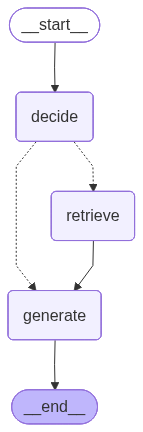

In [33]:
#Create the state graph

workflow = StateGraph(AgentState)

#Adding nodes
workflow.add_node("decide",decide_retrieval)
workflow.add_node("retrieve",retrieve_documents)
workflow.add_node("generate",generate_answer)

#Setting entery point
workflow.set_entry_point("decide")

#Adding conditional edgrs
workflow.add_conditional_edges(
    "decide",
    should_retrieve,
    {
        "retrieve":"retrieve",
        "generate":"generate"
    }
)
#Adding edges
workflow.add_edge("retrieve","generate")
workflow.add_edge("generate",END)

#Compiling Graph
app=workflow.compile()
app


Testing the Agentic System

In [34]:
def ask_question(question:str):
    """
    Helper function to ask a question and get an answer
    """
    initial_state={
        "question":question,
        "documents":[],
        "answer":"",
        "needs_retrieval":False
    }
    result = app.invoke(initial_state)
    return result

In [35]:
#Testing with a question that should trigger retrieval

question1 = "what is Hyperparameter and Compute Details"
result1 = ask_question(question1)
result1

{'question': 'what is Hyperparameter and Compute Details',
 'documents': [Document(id='b371fc1d-88a4-4d5c-a912-1c728b904bc6', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '..\\data\\pdf\\1706.03762v7.pdf', 'total_pages': 15, 'page': 2, 'page_label': '3'}, page_content='3.2 Attention\nAn attention function can be described as mapping a query and a set of key-value pairs to an output,\nwhere the query, keys, values, and output are all vectors. The output is computed as a weighted sum\n3'),
  Document(id='722f0baa-d714-4476-8638-372f16c63c3b', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keyword